## Preprocessing

This notebook starts from the complete CalFire database, subsets to the fire events we want to validate against, and saves those as a separate shapefile

In [1]:
import pandas as pd
import geopandas as gpd
import fiona
import numpy as np
import requests 
import sys 
from src import config 

In [2]:
calfire = gpd.read_file(config.PATH_CALFIRE)
calfire.head()

/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: data/California_Fire_Perimeters_(all).shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


,YEAR_,STATE,AGENCY,UNIT_ID,FIRE_NAME,INC_NUM,ALARM_DATE,CONT_DATE,CAUSE,C_METHOD,OBJECTIVE,GIS_ACRES,COMMENTS,COMPLEX_NA,IRWINID,FIRE_NUM,COMPLEX_ID,DECADES,geometry
0,2025,CA,CDF,LDF,PALISADES,00000738,2025-01-07,2025-01-31,14,7,1,23448.900,None,None,{A7EA5D21-F882-44B8-BF64-44AB11059DC1},None,None,2020-January 2025,"MULTIPOLYGON (((-13193558.265 4032826.468, -13..."
1,2025,CA,CDF,LAC,EATON,00009087,2025-01-08,2025-01-31,14,7,1,14056.300,None,None,{72660ADC-B5EF-4D96-A33F-B4EA3740A4E3},None,None,2020-January 2025,"MULTIPOLYGON (((-13146936.686 4051222.067, -13..."
2,2025,CA,CDF,ANF,HUGHES,00250270,2025-01-22,2025-01-28,14,7,1,10396.800,None,None,{994072D2-E154-434A-BB95-6F6C94C40829},None,None,2020-January 2025,"MULTIPOLYGON (((-13197885.239 4107084.744, -13..."
3,2025,CA,CCO,VNC,KENNETH,00003155,2025-01-09,2025-02-04,14,2,1,998.738,from OES Intel 24,None,{842FB37B-7AC8-4700-BB9C-028BF753D149},None,None,2020-January 2025,"POLYGON ((-13211054.577 4051508.758, -13211051..."
4,2025,CA,CDF,LDF,HURST,00003294,2025-01-07,2025-01-09,14,7,1,831.385,None,None,{F4E810AD-CDF3-4ED4-B63F-03D43785BA7B},None,None,2020-January 2025,"POLYGON ((-13187991.688 4073306.403, -13187979..."


UNIT_ID
KNP    20
MNP    12
SMP     7
JTP     2
CNP     2
Name: count, dtype: int64


/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Field ALARM_DATE created as String field, though DateTime requested.
  ogr_write(
/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Field CONT_DATE created as String field, though DateTime requested.
  ogr_write(


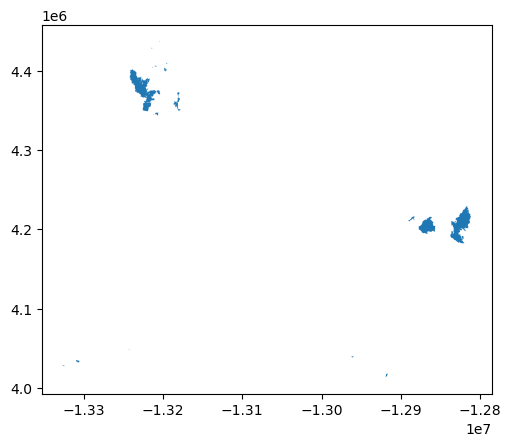

In [3]:
calfire_filtered_parks = calfire[
    (calfire['YEAR_'] > config.YEAR_START) & 
    (calfire['AGENCY'] == 'NPS') & 
    (calfire['UNIT_ID'].isin(config.PARKS))
].copy()

print(calfire_filtered_parks['UNIT_ID'].value_counts())
calfire_filtered_parks.plot()
calfire_filtered_parks.to_file(config.PATH_FIRES_VALIDATION)